In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("deadskull7/fer2013")

print("Path to dataset files:", path)

100%|██████████| 96.6M/96.6M [00:05<00:00, 19.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/deadskull7/fer2013/versions/1


In [ ]:
import os

In [ ]:
os.listdir(path)

['fer2013.csv']

In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import os

# convert string to integer
def atoi(s):
    n = 0
    for i in s:
        n = n*10 + ord(i) - ord("0")
    return n

# making folders
outer_names = ['test','train']
inner_names = ['angry', 'disgusted', 'fearful', 'happy', 'sad', 'surprised', 'neutral']
os.makedirs('data', exist_ok=True)
for outer_name in outer_names:
    os.makedirs(os.path.join('data',outer_name), exist_ok=True)
    for inner_name in inner_names:
        os.makedirs(os.path.join('data',outer_name,inner_name), exist_ok=True)

# to keep count of each category
angry = 0
disgusted = 0
fearful = 0
happy = 0
sad = 0
surprised = 0
neutral = 0
angry_test = 0
disgusted_test = 0
fearful_test = 0
happy_test = 0
sad_test = 0
surprised_test = 0
neutral_test = 0

img_width = 48
img_height = 48

df = pd.read_csv(path+'/fer2013.csv')

In [ ]:
df['Usage'].unique()

array(['Training', 'PublicTest', 'PrivateTest'], dtype=object)

In [ ]:
(df['Usage'] == 'PrivateTest').sum() + (df['Usage'] == 'PublicTest').sum()

np.int64(7178)

In [ ]:
training_count = (df['Usage'] == 'Training').sum()
testing_count = (df['Usage'] == 'PrivateTest').sum() + (df['Usage'] == 'PublicTest').sum()

print(f"{training_count} {testing_count}")

28709 7178


In [ ]:
TRAIN_PATH = "/content/data/train"
TEST_PATH = "/content/data/test"

In [ ]:
mat = np.zeros((48,48),dtype=np.uint8)
print("Saving images...")

# read the csv file line by line
for i in tqdm(range(len(df))):
    txt = df['pixels'][i]
    words = txt.split()

    # the image size is 48x48
    for j in range(img_width*img_height):
        xind = j // 48
        yind = j % 48
        mat[xind][yind] = atoi(words[j])

    img = Image.fromarray(mat)

    # train
    if i < training_count:
        if df['emotion'][i] == 0:
            img.save(TRAIN_PATH+'/angry/im'+str(angry)+'.png')
            angry += 1
        elif df['emotion'][i] == 1:
            img.save(TRAIN_PATH+'/disgusted/im'+str(disgusted)+'.png')
            disgusted += 1
        elif df['emotion'][i] == 2:
            img.save(TRAIN_PATH+'/fearful/im'+str(fearful)+'.png')
            fearful += 1
        elif df['emotion'][i] == 3:
            img.save(TRAIN_PATH+'/happy/im'+str(happy)+'.png')
            happy += 1
        elif df['emotion'][i] == 4:
            img.save(TRAIN_PATH+'/sad/im'+str(sad)+'.png')
            sad += 1
        elif df['emotion'][i] == 5:
            img.save(TRAIN_PATH+'/surprised/im'+str(surprised)+'.png')
            surprised += 1
        elif df['emotion'][i] == 6:
            img.save(TRAIN_PATH+'/neutral/im'+str(neutral)+'.png')
            neutral += 1

    # test
    else:
        if df['emotion'][i] == 0:
            img.save(TEST_PATH+'/angry/im'+str(angry_test)+'.png')
            angry_test += 1
        elif df['emotion'][i] == 1:
            img.save(TEST_PATH+'/disgusted/im'+str(disgusted_test)+'.png')
            disgusted_test += 1
        elif df['emotion'][i] == 2:
            img.save(TEST_PATH+'/fearful/im'+str(fearful_test)+'.png')
            fearful_test += 1
        elif df['emotion'][i] == 3:
            img.save(TEST_PATH+'/happy/im'+str(happy_test)+'.png')
            happy_test += 1
        elif df['emotion'][i] == 4:
            img.save(TEST_PATH+'/sad/im'+str(sad_test)+'.png')
            sad_test += 1
        elif df['emotion'][i] == 5:
            img.save(TEST_PATH+'/surprised/im'+str(surprised_test)+'.png')
            surprised_test += 1
        elif df['emotion'][i] == 6:
            img.save(TEST_PATH+'/neutral/im'+str(neutral_test)+'.png')
            neutral_test += 1

Saving images...


100%|██████████| 35887/35887 [01:21<00:00, 438.94it/s]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
def plot_model_history(model_history):
    """
    Plot Accuracy and Loss curves given the model_history
    """
    fig, axs = plt.subplots(1,2,figsize=(15,5))
    # summarize history for accuracy
    axs[0].plot(range(1,len(model_history.history['accuracy'])+1),model_history.history['accuracy'])
    axs[0].plot(range(1,len(model_history.history['val_accuracy'])+1),model_history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    # The following line was changed
    axs[0].set_xticks(np.arange(1,len(model_history.history['accuracy'])+1))  # Removed the second argument, or you can provide a list of labels here
    axs[0].legend(['train', 'val'], loc='best')
    # summarize history for loss
    axs[1].plot(range(1,len(model_history.history['loss'])+1),model_history.history['loss'])
    axs[1].plot(range(1,len(model_history.history['val_loss'])+1),model_history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    # The following line was changed
    axs[1].set_xticks(np.arange(1,len(model_history.history['loss'])+1))  # Removed the second argument, or you can provide a list of labels here
    axs[1].legend(['train', 'val'], loc='best')
    fig.savefig('plot.png')
    plt.show()

In [ ]:
train_dir = 'data/train'
val_dir = 'data/test'

num_train = training_count
num_val = testing_count
batch_size = 64
num_epoch = 50

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(48,48),
        batch_size=batch_size,
        color_mode="grayscale",
        class_mode='categorical')

validation_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(48,48),
        batch_size=batch_size,
        color_mode="grayscale",
        class_mode='categorical')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
class_indices = train_generator.class_indices
print(class_indices)

{'angry': 0, 'disgusted': 1, 'fearful': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprised': 6}


In [ ]:
from collections import Counter
import numpy as np

# Extract labels
labels = train_generator.classes

# Count occurrences
class_counts = Counter(labels)

# Total samples
total_samples = sum(class_counts.values())

# Compute class weights
class_weight = {cls: total_samples / (len(class_counts) * count) for cls, count in class_counts.items()}

In [ ]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(48,48,1)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7, activation='softmax'))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='categorical_crossentropy',optimizer=Adam(learning_rate=0.0001, decay=1e-6),metrics=['accuracy'])
model_info = model.fit(
        train_generator,
        steps_per_epoch=num_train // batch_size,
        epochs=num_epoch,
        validation_data=validation_generator,
        validation_steps=num_val // batch_size,
         class_weight=class_weight)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


448/448 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.1386 - loss: 1.9529 - val_accuracy: 0.1819 - val_loss: 1.9291
Epoch 2/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.1094 - loss: 2.2488

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1094 - loss: 2.2488 - val_accuracy: 0.1752 - val_loss: 1.9301
Epoch 3/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.2122 - loss: 1.8830 - val_accuracy: 0.3225 - val_loss: 1.7477
Epoch 4/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3125 - loss: 1.4901 - val_accuracy: 0.3324 - val_loss: 1.7401
Epoch 5/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.3285 - loss: 1.7275 - val_accuracy: 0.3894 - val_loss: 1.6272
Epoch 6/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2500 - loss: 2.1015 - val_accuracy: 0.3917 - val_loss: 1.6240
Epoch 7/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.3651 - loss: 1.6571 - val_accuracy: 0.4166 - val_loss: 1.5419
Epoch 8/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3906 - loss: 1.3446 - val_accuracy: 0.4170 - val_loss: 1.5376
Epoch 9/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.4056 - loss: 1.5555 - val_accuracy: 0.449

In [ ]:
model.save_weights('emotion.weights.h5')

In [ ]:
model.save('emotion_model.h5')

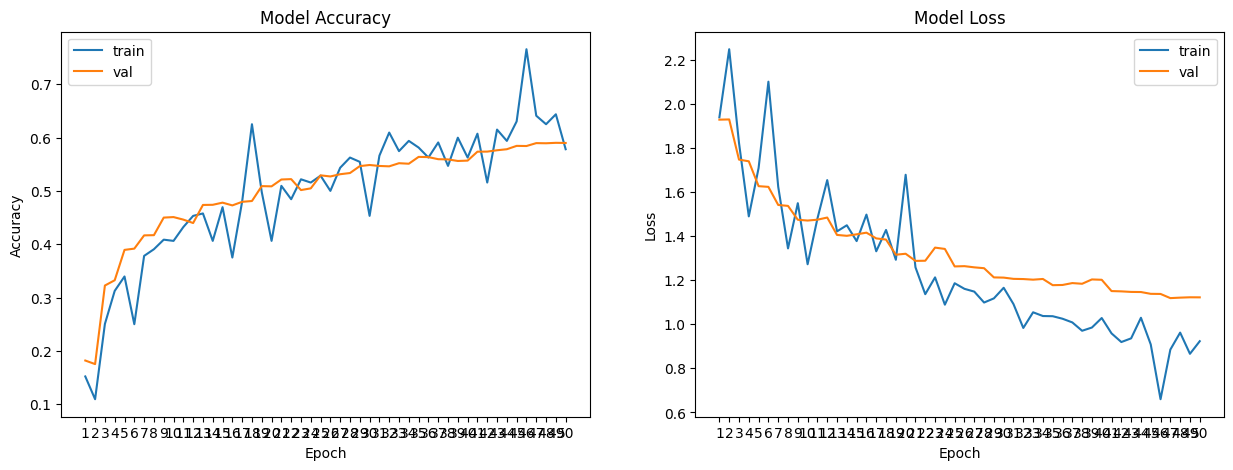

In [ ]:
plot_model_history(model_info)